In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
plt.rc('font', family='NanumGothic')

In [2]:
df = pd.read_csv('전체병합_전처리.csv',index_col=0)

df_train=df[df['계약년도']!=2023].drop(columns=['구','계약년도','계약월','인구수'])
df_test=df[df['계약년도']==2023].drop(columns=['구','계약년도','계약월','인구수'])

X = df_train.drop(columns='평당가격')
y = df_train['평당가격']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=34)

전진선택법
=

In [3]:
## 전진 단계별 선택법

# feature 및 target
variables = X_train.columns.tolist() 
y = y_train 

# 선택된 변수들 list 생성
forward_valriables = []

# 전진선택시 P 값을 고려할 때, 선택과 제거 임계치 설정    
sl_enter = 0.05
sl_remove = 0.05

# 각 스텝별로 선택된 변수들
sv_per_step = [] 
# 각 스텝별 수정된 결정계수
adj_r_squared_list = []
# 스텝
steps = []
step = 0


while len(variables) > 0:
    remainder = list(set(variables) - set(forward_valriables))
    pval = pd.Series(index=remainder) ## 변수의 p-value
    ## 기존에 포함된 변수와 새로운 변수 하나씩 돌아가면서 
    ## 선형 모형을 적합한다.
    for col in remainder: 
        X = X_train[forward_valriables+[col]]
        X = sm.add_constant(X)
        model = sm.OLS(y,X).fit(disp=0)
        pval[col] = model.pvalues[col]
 
    min_pval = pval.min()
    if min_pval < sl_enter: ## 최소 p-value 값이 기준 값보다 작으면 포함
        forward_valriables.append(pval.idxmin())
        ## 선택된 변수들에대해서
        ## 어떤 변수를 제거할지 고른다.
        while len(forward_valriables) > 0:
            selected_X = X_train[forward_valriables]
            selected_X = sm.add_constant(selected_X)
            selected_pval = sm.OLS(y,selected_X).fit(disp=0).pvalues[1:] ## 절편항의 p-value는 뺀다
            max_pval = selected_pval.max()
            if max_pval >= sl_remove: ## 최대 p-value값이 기준값보다 크거나 같으면 제외
                remove_variable = selected_pval.idxmax()
                forward_valriables.remove(remove_variable)
            else:
                break
        
        step += 1
        steps.append(step)
        adj_r_squared = sm.OLS(y,sm.add_constant(X_train[forward_valriables])).fit(disp=0).rsquared_adj
        adj_r_squared_list.append(adj_r_squared)
        sv_per_step.append(forward_valriables.copy())
    else:
        break

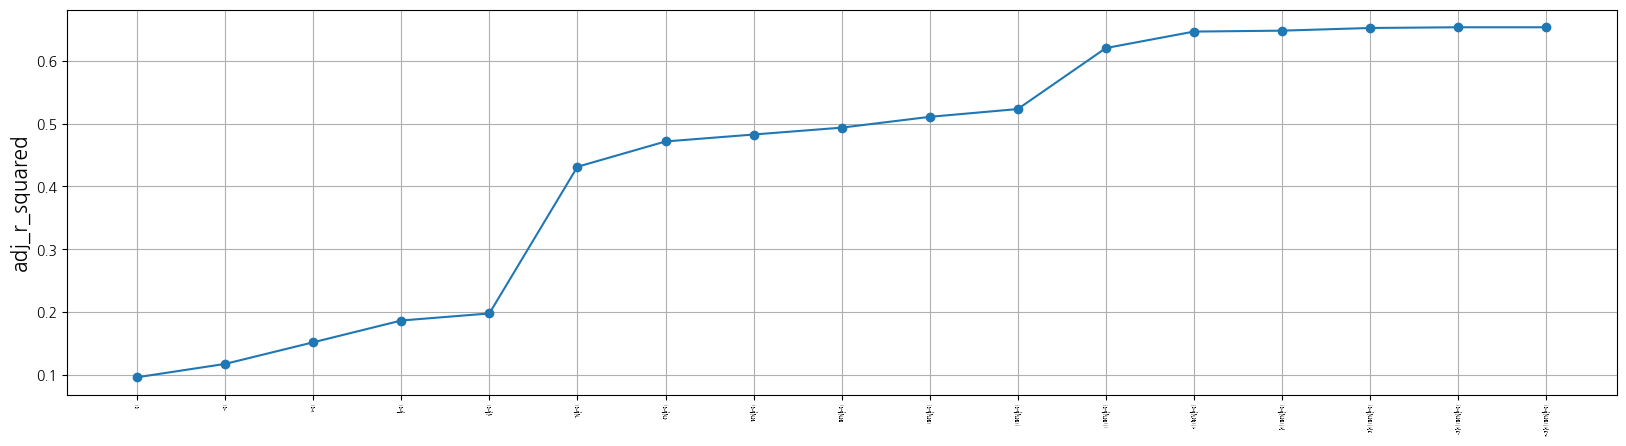

In [4]:
fig = plt.figure(figsize=(20,5))
fig.set_facecolor('white')
 
font_size = 15
plt.xticks(steps,[f'step {s}\n'+'\n'.join(sv_per_step[i]) for i,s in enumerate(steps)], fontsize=1)
plt.plot(steps, adj_r_squared_list, marker='o')
    
plt.ylabel('adj_r_squared',fontsize=font_size)
plt.grid(True)
plt.show()

In [5]:
forward_valriables

['난방종류',
 '달러',
 '세대수',
 '가까운역과의거리',
 'GDP성장률',
 '공시지가',
 '건축경과',
 '전용면적',
 '주차대수',
 'latitude',
 'longitude',
 'Cluster',
 '금리',
 '혼인10년차',
 '평균연령',
 '층',
 '변동']

단계선택법
=

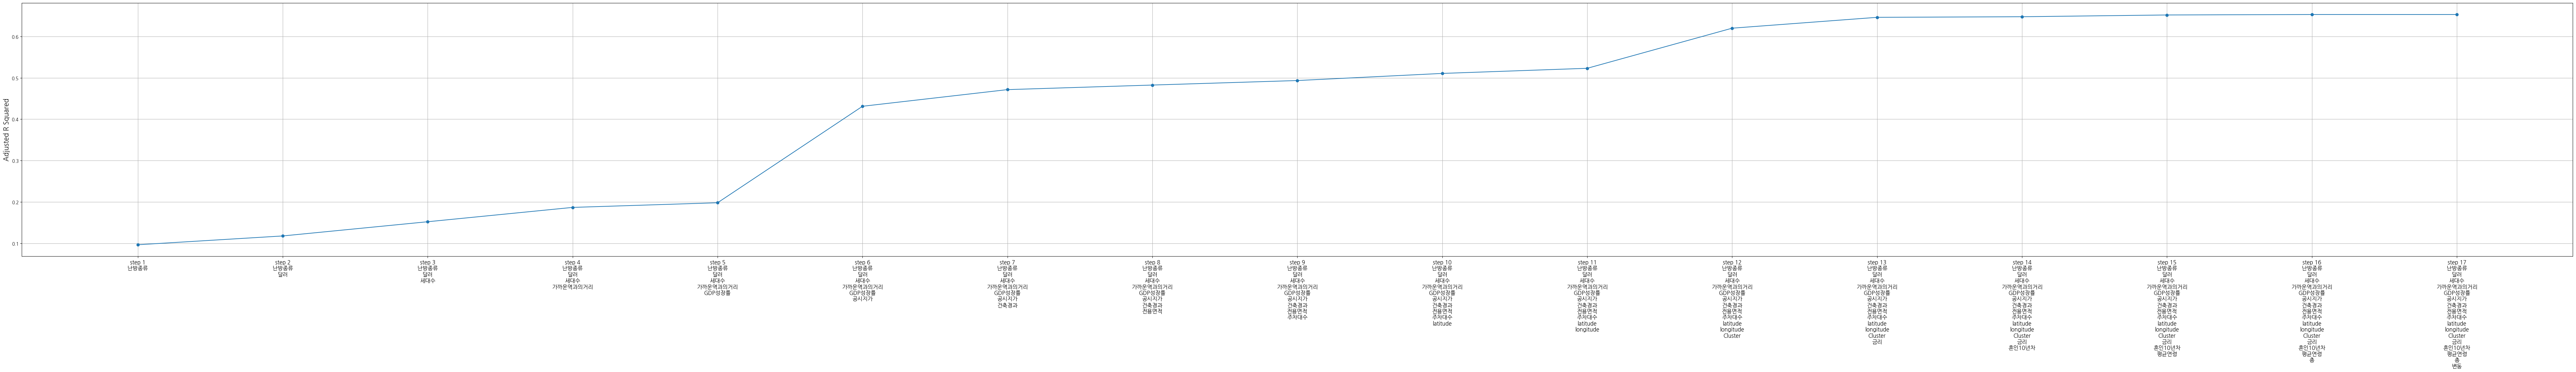

In [6]:
def stepwise_feature_selection(X_train, y_train, variables=X_train.columns.tolist() ):
    import statsmodels.api as sm
    import matplotlib.pyplot as plt
    import warnings
    warnings.filterwarnings("ignore")
    
    y = y_train ## 반응 변수

    selected_variables = [] ## 선택된 변수들
    sl_enter = 0.05
    sl_remove = 0.05
    
    sv_per_step = [] ## 각 스텝별로 선택된 변수들
    adjusted_r_squared = [] ## 각 스텝별 수정된 결정계수
    steps = [] ## 스텝
    step = 0
    while len(variables) > 0:
        remainder = list(set(variables) - set(selected_variables))
        pval = pd.Series(index=remainder) ## 변수의 p-value
        ## 기존에 포함된 변수와 새로운 변수 하나씩 돌아가면서 
        ## 선형 모형을 적합한다.
        for col in remainder: 
            X = X_train[selected_variables+[col]]
            X = sm.add_constant(X)
            model = sm.OLS(y,X).fit(disp=0)
            pval[col] = model.pvalues[col]
    
        min_pval = pval.min()
        if min_pval < sl_enter: ## 최소 p-value 값이 기준 값보다 작으면 포함
            selected_variables.append(pval.idxmin())
            ## 선택된 변수들에대해서
            ## 어떤 변수를 제거할지 고른다.
            while len(selected_variables) > 0:
                selected_X = X_train[selected_variables]
                selected_X = sm.add_constant(selected_X)
                selected_pval = sm.OLS(y,selected_X).fit(disp=0).pvalues[1:] ## 절편항의 p-value는 뺀다
                max_pval = selected_pval.max()
                if max_pval >= sl_remove: ## 최대 p-value값이 기준값보다 크거나 같으면 제외
                    remove_variable = selected_pval.idxmax()
                    selected_variables.remove(remove_variable)
                else:
                    break
            
            step += 1
            steps.append(step)
            adj_r_squared = sm.OLS(y,sm.add_constant(X_train[selected_variables])).fit(disp=0).rsquared_adj
            adjusted_r_squared.append(adj_r_squared)
            sv_per_step.append(selected_variables.copy())
        else:
            break

    fig = plt.figure(figsize=(100,10))
    fig.set_facecolor('white')
    
    font_size = 15
    plt.xticks(steps,[f'step {s}\n'+'\n'.join(sv_per_step[i]) for i,s in enumerate(steps)], fontsize=12)
    plt.plot(steps,adjusted_r_squared, marker='o')
      
    plt.ylabel('Adjusted R Squared',fontsize=font_size)
    plt.grid(True)
    plt.show()

    return selected_variables
    

selected_variables = stepwise_feature_selection(X_train, y_train)

In [7]:
selected_variables

['난방종류',
 '달러',
 '세대수',
 '가까운역과의거리',
 'GDP성장률',
 '공시지가',
 '건축경과',
 '전용면적',
 '주차대수',
 'latitude',
 'longitude',
 'Cluster',
 '금리',
 '혼인10년차',
 '평균연령',
 '층',
 '변동']

PCA
=

In [8]:
# 객체 생성
scaler = StandardScaler()   

# 훈련데이터의 분포 저장
scaler.fit(df_train)

# 훈련 데이터 스케일링
df_scale = scaler.transform(df_train)

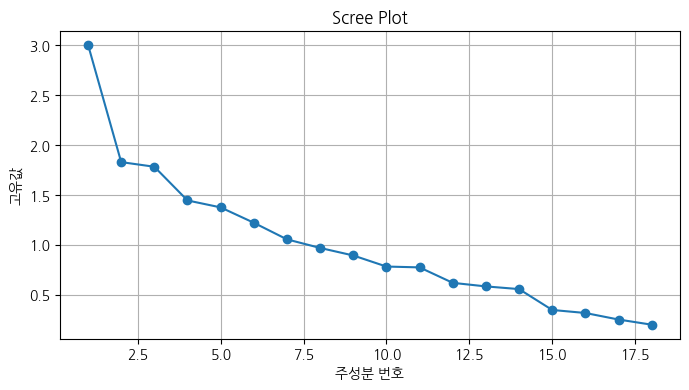

In [9]:
plt.rc('font', family='NanumGothic')

mean = np.mean(df_scale, axis=0)
centered_df = df_scale - mean  # 데이터를 평균으로 중심화
cov_matrix = np.cov(centered_df, rowvar=False)  # 공분산 행렬 계산
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # 고유값과 고유벡터 계산

# 고유값을 크기 순서대로 정렬
eigenvalues_sorted = np.sort(eigenvalues)[::-1]

# Scree plot 그리기
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues_sorted, marker='o', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('주성분 번호')
plt.ylabel('고유값')
plt.grid()
plt.show()

In [10]:
pca = PCA(n_components=17) # 주성분을 몇개로 할지 결정
printcipalComponents = pca.fit_transform(X)
principalDf = pd.DataFrame(data=printcipalComponents)

pca.explained_variance_ratio_

array([5.07959778e-01, 2.91259276e-01, 1.99529935e-01, 1.16809769e-03,
       3.47375614e-05, 3.05910357e-05, 1.46413688e-05, 1.45892054e-06,
       5.97363250e-07, 3.44289033e-07, 2.96082860e-07, 7.08046366e-08,
       6.23430533e-08, 6.03087527e-08, 4.93665775e-08, 3.25351518e-09,
       6.70963328e-10])

In [11]:
principalDf.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,1790.534546,-51.776263,-371.717936,24.911726,-8.010185,15.785442,-2.561032,0.917574,-1.555181,0.702133,-1.304206,0.184776,0.005918,0.318134,-0.222777,0.040224,-0.056551
1,-870.300429,-338.567355,-77.519400,189.753668,21.335039,2.247194,-1.203762,-2.104461,-1.685155,1.155447,0.878252,1.069155,-0.227805,0.002305,0.289956,-0.071225,-0.039104
2,-880.088786,814.157119,-336.509126,-79.082476,-6.365839,15.174487,0.006376,-0.622424,0.121170,-0.590400,0.313603,0.164814,0.014214,-0.234135,0.250824,-0.031269,-0.026493
3,105.833805,-235.774835,-423.809718,16.035125,-1.710078,-11.021706,-6.137263,2.022878,-2.221228,0.524223,-1.138452,-0.246307,-0.030821,-0.212935,0.113565,-0.140789,0.012260
4,-550.313914,560.040326,603.824542,42.122373,2.003063,0.398320,4.235951,3.084434,2.969692,-0.371806,-0.337906,-0.389300,-0.100853,-0.323045,-0.270122,0.049569,0.013638


L1 Regularization
=

In [12]:
alpha = 1.0  # 규제 강도 조절 매개변수 (alpha를 조절하여 규제 강도 조절 가능)
lasso_model = Lasso(alpha=alpha)

# 모델 훈련
lasso_model.fit(X_train, y_train)

# 각 변수(특성)의 가중치 확인
coefficients = lasso_model.coef_

# 결과 출력
for feature, coef in zip(X_train.columns, coefficients):
    if coef >= 0:
        print(f'Feature: {feature}, Coefficient: {coef}')

Feature: 층, Coefficient: 10.099215231594389
Feature: longitude, Coefficient: 1683.2810171708302
Feature: 세대수, Coefficient: 0.2717446384218795
Feature: 주차대수, Coefficient: 282.28548385346124
Feature: 공시지가, Coefficient: 0.7926316440694731
Feature: 달러, Coefficient: 4.0687944575560815
Feature: 변동, Coefficient: 2.863025497849807
Feature: GDP성장률, Coefficient: 97.99340277255634
Feature: Cluster, Coefficient: 553.2292311400669


In [13]:
#df.to_csv('전체병합_전처리.csv')